### Build LLM GPT2 from Scratch
1. Implement GPTDataset, a data preparation
2. Create PyTorch Dataset and DataLoader
3. Build the Casual Attention Mechanism
4. Implement the Multi Head
5. Build the LayerNorm / RMSNorm
6. Build the GELu and Feedforward(MLP)
7. Combine all in a Transformer Block
8. Build the GPT Model using 8 Transformer Blocks, and add the head layer, and softmax
9. Test First without training and optimization
10. Now Pretrain it
11. Build end to end on Youtube

In [167]:
import torch
import torch.nn as nn 
from importlib.metadata import version
import tiktoken
import numpy as np
import tensorflow as tf 

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.4.4
tiktoken version: 0.12.0
torch version: 2.11.0
tensorflow version: 2.21.0


In [168]:
from torch.utils.data import Dataset, DataLoader

class GPTDataset(Dataset):
    def __init__(self, txt, tokenizer, max_length=None, stride=None):
        self.input_ids = []
        self.target_ids = []
        # Tokenize the entire text
        self.token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(self.token_ids) - max_length, stride):
            input_chunk = self.token_ids[i : i + max_length]
            target_chunk = self.token_ids[i+1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))


emb = nn.Embedding(50257, 768)
tokenizer = tiktoken.get_encoding("gpt2")
ids = tokenizer.encode("Every effort moves you")
ids

[6109, 3626, 6100, 345]

In [169]:
emb(torch.tensor(ids))

tensor([[ 1.0259, -1.3087,  2.2181,  ...,  1.4525,  1.1138, -0.1973],
        [ 0.8876, -0.5986, -0.1476,  ...,  0.9548,  1.1676, -0.7904],
        [-0.0566, -0.4799,  0.4108,  ...,  1.1910, -1.3172,  1.3094],
        [-0.8166, -0.9052,  1.4776,  ...,  0.1637, -0.2772,  0.0268]],
       grad_fn=<EmbeddingBackward0>)

In [170]:
emb(torch.tensor(ids)).shape

torch.Size([4, 768])

In [171]:
GPTDataset(txt="Every effort moves you closer to your dream", tokenizer=tokenizer, max_length=4, stride=128).token_ids

[6109, 3626, 6100, 345, 5699, 284, 534, 4320]

In [172]:
GPTDataset(txt="Every effort moves you closer to your dream", tokenizer=tokenizer, max_length=4, stride=128).input_ids

[tensor([6109, 3626, 6100,  345])]

In [173]:
GPTDataset(txt="Every effort moves you closer to your dream", tokenizer=tokenizer, max_length=4, stride=2).target_ids

[tensor([3626, 6100,  345, 5699]), tensor([ 345, 5699,  284,  534])]

In [174]:
GPTDataset(txt="Every effort moves you closer to your dream", tokenizer=tokenizer, max_length=4, stride=2).input_ids

[tensor([6109, 3626, 6100,  345]), tensor([6100,  345, 5699,  284])]

In [175]:
from torch.utils.data import Dataset, DataLoader

class GPTDataset(Dataset):
    def __init__(self, txt, tokenizer, max_length=None, stride=None):
        self.input_ids = []
        self.target_ids = []
        # Tokenize the entire text
        self.token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        if len(self.token_ids) <= max_length:
            raise ValueError(
                f"Text is too short for max_length={max_length}. "
                f"Got {len(self.token_ids)} tokens; need more than {max_length}."
            )

        # Use sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(self.token_ids) - max_length, stride):
            input_chunk = self.token_ids[i : i + max_length]
            target_chunk = self.token_ids[i+1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

emb = nn.Embedding(50257, 768)
tokenizer = tiktoken.get_encoding("gpt2")
ids = tokenizer.encode("Every effort moves you")
ids

[6109, 3626, 6100, 345]

In [176]:
tokenizer.encode("Every effort moves you closer to your dream")

[6109, 3626, 6100, 345, 5699, 284, 534, 4320]

In [177]:
GPTDataset(txt="Every effort moves you closer to your dream", tokenizer=tokenizer, max_length=4, stride=2).target_ids

[tensor([3626, 6100,  345, 5699]), tensor([ 345, 5699,  284,  534])]

In [178]:
GPTDataset(txt="Every effort moves you closer to your dream", tokenizer=tokenizer, max_length=4, stride=2)[0]

(tensor([6109, 3626, 6100,  345]), tensor([3626, 6100,  345, 5699]))

In [179]:
GPTDataset(txt="Every effort moves you closer to your dream", tokenizer=tokenizer, max_length=4, stride=2)[1]

(tensor([6100,  345, 5699,  284]), tensor([ 345, 5699,  284,  534]))

In [180]:
def create_dataloader(txt, batch_size=4, max_length=256, stride=128, 
        shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDataset(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers
    )
    return dataloader

dataloader = create_dataloader(txt="Every effort moves you closer to your dream", max_length=4, stride=1)

In [181]:
for input_batch, target_batch in dataloader:
    print("Inputs:", input_batch)
    print("Targets:", target_batch)

Inputs: tensor([[ 345, 5699,  284,  534],
        [6109, 3626, 6100,  345],
        [6100,  345, 5699,  284],
        [3626, 6100,  345, 5699]])
Targets: tensor([[5699,  284,  534, 4320],
        [3626, 6100,  345, 5699],
        [ 345, 5699,  284,  534],
        [6100,  345, 5699,  284]])


In [182]:
tokenizer.encode("Every effort moves you closer to your dream")

[6109, 3626, 6100, 345, 5699, 284, 534, 4320]

In [183]:
data_iter = iter(dataloader)
first_batch = next(data_iter)
inputs, targets = first_batch

print(inputs)
print(targets)

tensor([[6109, 3626, 6100,  345],
        [6100,  345, 5699,  284],
        [3626, 6100,  345, 5699],
        [ 345, 5699,  284,  534]])
tensor([[3626, 6100,  345, 5699],
        [ 345, 5699,  284,  534],
        [6100,  345, 5699,  284],
        [5699,  284,  534, 4320]])


In [184]:
def create_dataloader(txt, batch_size=4, max_length=256, stride=128, 
        shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")

    dataset = GPTDataset(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers
    )
    return dataloader

dataloader = create_dataloader(txt="Every effort moves you closer to your dream", max_length=4, stride=1, batch_size=1)

In [185]:
data_iter = iter(dataloader)
first_batch = next(data_iter)
inputs, targets = first_batch

print(inputs)
print(targets)

tensor([[3626, 6100,  345, 5699]])
tensor([[6100,  345, 5699,  284]])


In [186]:
GPT_CONFIG_124m = {
    "vocab_size": 50257,  #Vocabulary size
    "context_length": 1024,   # Context length
    "emb_dim": 768,   # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,   # Number of layers
    "drop_rate": 0.1,   # Dropout rate
    "qkv_bias": False   # Query-key-Value bias
}

In [187]:
class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)

    def forward(self, x):
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        attn_scores = q @ k.transpose(-2, -1)
        attn_weights = torch.softmax(attn_scores / k.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ v
        return self.out_proj(context_vec)

In [188]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

sa = SelfAttention(3, 6)
sa(inputs)

tensor([[ 0.3730,  0.2229, -0.1054, -0.2512, -0.1074, -0.5242],
        [ 0.3750,  0.2219, -0.1064, -0.2528, -0.1076, -0.5246],
        [ 0.3751,  0.2219, -0.1065, -0.2529, -0.1076, -0.5245],
        [ 0.3743,  0.2227, -0.1054, -0.2522, -0.1078, -0.5257],
        [ 0.3759,  0.2213, -0.1072, -0.2535, -0.1076, -0.5239],
        [ 0.3737,  0.2232, -0.1048, -0.2517, -0.1078, -0.5262]],
       grad_fn=<AddmmBackward0>)

In [189]:
id = emb(torch.tensor(tokenizer.encode("Every effort moves you closer to your dream")))
id.shape

torch.Size([8, 768])

In [190]:
sa = SelfAttention(768, 10)
sa(id)

tensor([[ 0.1267,  0.2638, -0.1418,  0.3314, -0.0985, -0.3384, -0.1979,  0.2040,
         -0.1399,  0.0710],
        [ 0.1371,  0.2585, -0.2051,  0.3453, -0.1638, -0.3178, -0.2069,  0.2203,
         -0.0661,  0.0368],
        [ 0.1955,  0.2650, -0.2687,  0.3432, -0.1883, -0.2825, -0.2291,  0.2161,
          0.0325, -0.0093],
        [ 0.1376,  0.2428, -0.2218,  0.3579, -0.1693, -0.2873, -0.1913,  0.2047,
         -0.0108,  0.0251],
        [ 0.1904,  0.2895, -0.2028,  0.3329, -0.1386, -0.3035, -0.2128,  0.1958,
         -0.0465,  0.0346],
        [ 0.1647,  0.2616, -0.1799,  0.3609, -0.1182, -0.3046, -0.1937,  0.1759,
         -0.0589,  0.0454],
        [ 0.1596,  0.2326, -0.2161,  0.3330, -0.1239, -0.2814, -0.2278,  0.2128,
         -0.0743,  0.0369],
        [ 0.1588,  0.2450, -0.2760,  0.2956, -0.2015, -0.3070, -0.2730,  0.3003,
         -0.0019, -0.0138]], grad_fn=<AddmmBackward0>)

In [191]:
sa = SelfAttention(768, 10)
sa(id).shape

torch.Size([8, 10])

In [192]:
class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)

    def forward(self, x):
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        attn_scores = q @ k.transpose(-2, -1)
        attn_weights = torch.softmax(attn_scores / k.shape[-1]**0.5, dim=-1)
        return attn_weights

In [193]:
sa = SelfAttention(768, 10)
sa(id).shape

torch.Size([8, 8])

In [194]:
sa(id)

tensor([[0.1321, 0.1141, 0.1214, 0.0937, 0.0917, 0.1179, 0.1012, 0.2280],
        [0.1965, 0.1153, 0.1164, 0.1527, 0.0891, 0.1148, 0.1096, 0.1055],
        [0.0531, 0.2439, 0.0721, 0.0885, 0.1374, 0.1226, 0.1009, 0.1814],
        [0.0630, 0.1618, 0.1448, 0.0722, 0.0682, 0.1083, 0.1203, 0.2615],
        [0.1004, 0.1622, 0.1874, 0.0567, 0.0661, 0.1066, 0.0886, 0.2321],
        [0.2049, 0.0659, 0.0821, 0.1499, 0.2162, 0.0888, 0.1343, 0.0579],
        [0.0977, 0.1204, 0.1218, 0.0801, 0.1622, 0.1069, 0.1250, 0.1860],
        [0.2263, 0.1084, 0.0807, 0.1174, 0.1469, 0.1073, 0.0971, 0.1158]],
       grad_fn=<SoftmaxBackward0>)

In [195]:
sum(sa(id)[0])

tensor(1., grad_fn=<AddBackward0>)

In [196]:
sa(id).sum(dim=-1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)

In [197]:
torch.triu(inputs, diagonal=0)

tensor([[0.4300, 0.1500, 0.8900],
        [0.0000, 0.8700, 0.6600],
        [0.0000, 0.0000, 0.6400],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000]])

In [198]:
torch.triu(inputs, diagonal=1)

tensor([[0.0000, 0.1500, 0.8900],
        [0.0000, 0.0000, 0.6600],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000]])

The `diagonal` argument controls which diagonal is the cutoff:

- `diagonal=0` (default) → includes the main diagonal
- `diagonal=1` → shifts the cutoff up by one, excluding the main diagonal too
- `diagonal=-1` → shifts down by one, including one diagonal below the main

In [199]:
torch.triu(torch.ones(10, 10), diagonal=1)

tensor([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [200]:
input = torch.randn(size=(5, 5))
input

tensor([[-0.8039,  0.8991, -0.4470,  0.7517,  1.5926],
        [ 1.0873,  0.4040,  0.3855, -0.6260,  0.2107],
        [-0.2916,  1.1967, -0.1791,  1.2084, -0.4157],
        [-0.2636,  1.0991, -0.1292, -1.7016,  0.1708],
        [-0.5335, -0.9755, -0.5685,  0.7854,  0.8101]])

In [201]:
import torch

x = torch.arange(1, 26, dtype=torch.float).reshape(5, 5)
print(x)
# tensor([[ 1,  2,  3,  4],
#         [ 5,  6,  7,  8],
#         [ 9, 10, 11, 12],
#         [13, 14, 15, 16]])

tensor([[ 1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10.],
        [11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20.],
        [21., 22., 23., 24., 25.]])


In [202]:
torch.triu(x, diagonal=1)

tensor([[ 0.,  2.,  3.,  4.,  5.],
        [ 0.,  0.,  8.,  9., 10.],
        [ 0.,  0.,  0., 14., 15.],
        [ 0.,  0.,  0.,  0., 20.],
        [ 0.,  0.,  0.,  0.,  0.]])

In [203]:
mask = torch.triu(torch.ones(5, 5), diagonal=1)
mask

tensor([[0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]])

In [204]:
mask = mask.bool()
mask

tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])

In [205]:
x.masked_fill_(mask, float("-inf"))
x

tensor([[ 1., -inf, -inf, -inf, -inf],
        [ 6.,  7., -inf, -inf, -inf],
        [11., 12., 13., -inf, -inf],
        [16., 17., 18., 19., -inf],
        [21., 22., 23., 24., 25.]])

In [206]:
torch.softmax(x, dim=-1)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2689, 0.7311, 0.0000, 0.0000, 0.0000],
        [0.0900, 0.2447, 0.6652, 0.0000, 0.0000],
        [0.0321, 0.0871, 0.2369, 0.6439, 0.0000],
        [0.0117, 0.0317, 0.0861, 0.2341, 0.6364]])

In [207]:
## Implementing the Mask attention

class CasualAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        # Upper traiangular mask not a learnable param -> register as buffer
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
        
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        print(q.shape)
        print(k.shape)

        attn_scores = q @ k.transpose(-2, -1)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        print(attn_scores)
        attn_weights = torch.softmax(attn_scores / k.shape[-1]**0.5, dim=-1)
        print(attn_weights)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ v
        return context_vec

In [208]:
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [209]:
x = inputs.unsqueeze(0)
x.shape

torch.Size([1, 6, 3])

In [210]:
x

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

In [211]:
torch.manual_seed(123)  # so weights are reproducible
ca = CasualAttention(d_in=3, d_out=5, context_length=6, dropout=0.0)
ca(x)

torch.Size([1, 6, 5])
torch.Size([1, 6, 5])
tensor([[[-0.2541,    -inf,    -inf,    -inf,    -inf,    -inf],
         [-0.4388, -0.6557,    -inf,    -inf,    -inf,    -inf],
         [-0.4341, -0.6496, -0.6458,    -inf,    -inf,    -inf],
         [-0.2486, -0.3847, -0.3811, -0.2127,    -inf,    -inf],
         [-0.2277, -0.3571, -0.3577, -0.1863, -0.2684,    -inf],
         [-0.3094, -0.4661, -0.4605, -0.2595, -0.2306, -0.3302]]],
       grad_fn=<MaskedFillBackward0>)
tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5242, 0.4758, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3549, 0.3223, 0.3228, 0.0000, 0.0000, 0.0000],
         [0.2564, 0.2413, 0.2417, 0.2606, 0.0000, 0.0000],
         [0.2046, 0.1931, 0.1930, 0.2084, 0.2009, 0.0000],
         [0.1690, 0.1576, 0.1580, 0.1728, 0.1751, 0.1675]]],
       grad_fn=<SoftmaxBackward0>)


tensor([[[ 0.4772,  0.1063, -0.5967, -0.2754,  0.0189],
         [ 0.5722,  0.2927, -0.6368, -0.2762,  0.2083],
         [ 0.6059,  0.3579, -0.6506, -0.2736,  0.2721],
         [ 0.5407,  0.3466, -0.5695, -0.2430,  0.2793],
         [ 0.5272,  0.3364, -0.5471, -0.1999,  0.2417],
         [ 0.5021,  0.3384, -0.5178, -0.2072,  0.2680]]],
       grad_fn=<UnsafeViewBackward0>)

In [212]:
ca(x).shape

torch.Size([1, 6, 5])
torch.Size([1, 6, 5])
tensor([[[-0.2541,    -inf,    -inf,    -inf,    -inf,    -inf],
         [-0.4388, -0.6557,    -inf,    -inf,    -inf,    -inf],
         [-0.4341, -0.6496, -0.6458,    -inf,    -inf,    -inf],
         [-0.2486, -0.3847, -0.3811, -0.2127,    -inf,    -inf],
         [-0.2277, -0.3571, -0.3577, -0.1863, -0.2684,    -inf],
         [-0.3094, -0.4661, -0.4605, -0.2595, -0.2306, -0.3302]]],
       grad_fn=<MaskedFillBackward0>)
tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5242, 0.4758, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3549, 0.3223, 0.3228, 0.0000, 0.0000, 0.0000],
         [0.2564, 0.2413, 0.2417, 0.2606, 0.0000, 0.0000],
         [0.2046, 0.1931, 0.1930, 0.2084, 0.2009, 0.0000],
         [0.1690, 0.1576, 0.1580, 0.1728, 0.1751, 0.1675]]],
       grad_fn=<SoftmaxBackward0>)


torch.Size([1, 6, 5])

In [213]:
ids = emb(torch.tensor(tokenizer.encode("Every effort moves you closer to your dream")))
ids

tensor([[ 0.1319,  0.1849,  0.1991,  ..., -0.1309,  0.8721, -1.2825],
        [-1.4166,  0.2492, -0.6834,  ...,  0.6753, -0.8693, -1.5869],
        [-0.2020, -0.4949,  0.1744,  ..., -0.7762,  0.2284,  0.7785],
        ...,
        [ 0.1627, -0.8328, -1.7487,  ..., -0.2896,  1.9444, -1.1526],
        [ 0.0254, -1.2329,  0.6234,  ...,  0.1873, -1.0044,  0.6503],
        [ 0.5061,  0.7298,  1.9796,  ...,  0.5946, -0.3151, -2.0057]],
       grad_fn=<EmbeddingBackward0>)

In [214]:
ids.shape

torch.Size([8, 768])

In [215]:
txt = "Every effort moves you closer to your dream so believe"

In [216]:
dataloader = create_dataloader(txt, 4, 5, 1)
data = iter(dataloader)
first_batch = next(data)
input_batch, target_batch = first_batch
print(input_batch)
print(f"{target_batch}")

tensor([[6109, 3626, 6100,  345, 5699],
        [3626, 6100,  345, 5699,  284],
        [ 345, 5699,  284,  534, 4320],
        [5699,  284,  534, 4320,  523]])
tensor([[3626, 6100,  345, 5699,  284],
        [6100,  345, 5699,  284,  534],
        [5699,  284,  534, 4320,  523],
        [ 284,  534, 4320,  523, 1975]])


In [217]:
input_batch

tensor([[6109, 3626, 6100,  345, 5699],
        [3626, 6100,  345, 5699,  284],
        [ 345, 5699,  284,  534, 4320],
        [5699,  284,  534, 4320,  523]])

In [218]:
emb(torch.tensor(input_batch)).shape

C:\Users\user\AppData\Local\Temp\ipykernel_27684\1408782483.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  emb(torch.tensor(input_batch)).shape


torch.Size([4, 5, 768])

In [219]:
ca = CasualAttention(d_in=768, d_out=5, context_length=10, dropout=0.0)
ca(emb(torch.tensor(input_batch)))

torch.Size([4, 5, 5])
torch.Size([4, 5, 5])
tensor([[[ 1.3161,    -inf,    -inf,    -inf,    -inf],
         [-0.4392, -0.3474,    -inf,    -inf,    -inf],
         [-0.4762, -1.0731, -0.0325,    -inf,    -inf],
         [ 0.7170,  0.5064,  0.1200, -0.1841,    -inf],
         [-0.0226,  0.0127, -1.9067,  0.6178,  0.0533]],

        [[-0.3474,    -inf,    -inf,    -inf,    -inf],
         [-1.0731, -0.0325,    -inf,    -inf,    -inf],
         [ 0.5064,  0.1200, -0.1841,    -inf,    -inf],
         [ 0.0127, -1.9067,  0.6178,  0.0533,    -inf],
         [-0.4663,  1.1647, -0.4308,  0.2721,  0.4878]],

        [[-0.1841,    -inf,    -inf,    -inf,    -inf],
         [ 0.6178,  0.0533,    -inf,    -inf,    -inf],
         [-0.4308,  0.2721,  0.4878,    -inf,    -inf],
         [ 0.8548, -0.5595,  0.5278, -0.0055,    -inf],
         [-0.1111,  0.1036, -0.6884,  0.6356,  0.1110]],

        [[ 0.0533,    -inf,    -inf,    -inf,    -inf],
         [ 0.2721,  0.4878,    -inf,    -inf,    -inf]

C:\Users\user\AppData\Local\Temp\ipykernel_27684\4105086500.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ca(emb(torch.tensor(input_batch)))


tensor([[[-1.2435,  0.5943,  0.6940,  0.6128, -0.4994],
         [-1.1059,  0.4082, -0.1009,  0.1760, -0.0590],
         [-0.7575,  0.1158,  0.3894, -0.4259,  0.0978],
         [-0.8213,  0.3546,  0.0443, -0.3283,  0.1392],
         [-0.6497,  0.2516,  0.0027, -0.3196,  0.1211]],

        [[-0.9738,  0.2296, -0.8638, -0.2432,  0.3637],
         [-0.5127, -0.1252,  0.2359, -0.9491,  0.3986],
         [-0.6412,  0.2524, -0.2329, -0.7297,  0.4116],
         [-0.4940,  0.1617, -0.1787, -0.5642,  0.2839],
         [-0.3702, -0.0737,  0.0608, -0.6722,  0.3659]],

        [[-0.6671,  0.9714, -0.7020, -0.6332,  0.4665],
         [-0.3373,  0.2253, -0.0856, -0.5513,  0.2248],
         [-0.2945, -0.0063, -0.1602, -0.4021,  0.3377],
         [-0.6250,  0.4613, -0.2590, -0.3837,  0.3101],
         [-0.4111,  0.3917, -0.0087, -0.1680,  0.1584]],

        [[ 0.0872, -0.7352,  0.7077, -0.4459, -0.0864],
         [-0.1650, -0.3460,  0.0281, -0.3217,  0.2929],
         [-0.6047,  0.2156, -0.0456, -0.26

In [220]:
ca(emb(torch.tensor(input_batch))).shape

torch.Size([4, 5, 5])
torch.Size([4, 5, 5])
tensor([[[ 1.3161,    -inf,    -inf,    -inf,    -inf],
         [-0.4392, -0.3474,    -inf,    -inf,    -inf],
         [-0.4762, -1.0731, -0.0325,    -inf,    -inf],
         [ 0.7170,  0.5064,  0.1200, -0.1841,    -inf],
         [-0.0226,  0.0127, -1.9067,  0.6178,  0.0533]],

        [[-0.3474,    -inf,    -inf,    -inf,    -inf],
         [-1.0731, -0.0325,    -inf,    -inf,    -inf],
         [ 0.5064,  0.1200, -0.1841,    -inf,    -inf],
         [ 0.0127, -1.9067,  0.6178,  0.0533,    -inf],
         [-0.4663,  1.1647, -0.4308,  0.2721,  0.4878]],

        [[-0.1841,    -inf,    -inf,    -inf,    -inf],
         [ 0.6178,  0.0533,    -inf,    -inf,    -inf],
         [-0.4308,  0.2721,  0.4878,    -inf,    -inf],
         [ 0.8548, -0.5595,  0.5278, -0.0055,    -inf],
         [-0.1111,  0.1036, -0.6884,  0.6356,  0.1110]],

        [[ 0.0533,    -inf,    -inf,    -inf,    -inf],
         [ 0.2721,  0.4878,    -inf,    -inf,    -inf]

C:\Users\user\AppData\Local\Temp\ipykernel_27684\4033398394.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ca(emb(torch.tensor(input_batch))).shape


torch.Size([4, 5, 5])

In [221]:
## A very Naive Multi Head Attention using the casual mask above
## Implementing the Mask attention

class CasualAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        # Upper traiangular mask not a learnable param -> register as buffer
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
        
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        attn_scores = q @ k.transpose(-2, -1)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(attn_scores / k.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ v
        return context_vec

class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.n_heads = n_heads
        self.AttentionHeads = nn.ModuleList(
            [CasualAttention(d_in, d_out, context_length, dropout, qkv_bias=False) 
             for i in range(self.n_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.AttentionHeads], dim=-1)
        # Final output shape: (batch, num_tokens, d_out * n_heads). 

In [222]:
x = inputs.unsqueeze(0)
x.shape

torch.Size([1, 6, 3])

In [223]:
heads = MultiHeadAttention(8, d_in=3, d_out=2, context_length=10, dropout=0.0)
heads(x)

tensor([[[ 0.5042, -0.6110, -0.5226, -0.4819,  0.2766,  0.4121,  0.3301,
           0.2984, -0.0924, -0.0457,  0.2171, -0.6054,  0.0813, -0.3527,
          -0.0632, -0.4253],
         [ 0.7024, -0.6756, -0.6739, -0.4313,  0.4454,  0.4138,  0.1390,
           0.5211,  0.0101, -0.0447, -0.0059, -0.5389, -0.1188, -0.5050,
          -0.0622, -0.4196],
         [ 0.7590, -0.6910, -0.7241, -0.4156,  0.4936,  0.4096,  0.0838,
           0.5906,  0.0382, -0.0394, -0.0754, -0.5197, -0.1819, -0.5527,
          -0.0590, -0.4128],
         [ 0.6920, -0.6158, -0.6622, -0.3475,  0.4681,  0.3663,  0.0329,
           0.5452,  0.0581, -0.0451, -0.0960, -0.4325, -0.2010, -0.5126,
          -0.0574, -0.3679],
         [ 0.6326, -0.5499, -0.6188, -0.3553,  0.3865,  0.2983,  0.0800,
           0.5325,  0.0070,  0.0155, -0.1066, -0.4336, -0.1559, -0.4664,
          -0.0249, -0.3034],
         [ 0.6396, -0.5501, -0.6120, -0.3135,  0.4267,  0.3154,  0.0104,
           0.5215,  0.0463, -0.0198, -0.1184, -0.384

In [224]:
heads(x).shape

torch.Size([1, 6, 16])

In [225]:
ma = MultiHeadAttention(n_heads=8, d_in=768, d_out=5, context_length=10, dropout=0.0)
ma(emb(torch.tensor(input_batch))).shape

C:\Users\user\AppData\Local\Temp\ipykernel_27684\823229852.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ma(emb(torch.tensor(input_batch))).shape


torch.Size([4, 5, 40])

In [226]:
ma = MultiHeadAttention(n_heads=8, d_in=768, d_out=5, context_length=10, dropout=0.0)
ma(emb(torch.tensor(input_batch)))[0]

C:\Users\user\AppData\Local\Temp\ipykernel_27684\1867103133.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ma(emb(torch.tensor(input_batch)))[0]


tensor([[ 1.2010e+00,  2.6224e-01,  4.0628e-01, -2.5635e-02,  6.4822e-01,
          1.3368e+00, -3.1149e-01, -7.8409e-02,  8.3296e-01, -2.9485e-01,
         -4.6343e-01, -6.5287e-02, -5.8030e-01,  5.8590e-01,  8.4013e-02,
          4.5018e-01,  2.5024e-01, -7.0115e-01,  6.1529e-01,  1.5581e-01,
          5.8715e-01, -4.4401e-01,  1.0052e-01,  6.0057e-01, -4.2809e-01,
          2.6890e-01,  2.8593e-02, -8.0380e-03, -1.9894e-01,  2.3789e-01,
         -1.0402e-01, -5.1574e-01, -1.4107e+00, -9.5943e-01, -3.2488e-01,
         -2.0058e-01, -9.1893e-03,  3.0710e-01, -6.9927e-02,  5.6033e-01],
        [ 8.6408e-01, -1.6369e-02,  3.3421e-01, -2.0766e-01,  2.8126e-03,
         -8.3627e-02, -3.8234e-01,  7.8878e-02,  4.8748e-01, -4.5288e-01,
          2.0849e-01,  5.0658e-02,  3.1159e-01,  5.2543e-02, -4.5015e-01,
          3.2558e-01,  4.2396e-01,  5.0322e-01, -4.3233e-01, -3.3171e-01,
         -4.6425e-02, -5.2264e-01,  1.1517e-01,  1.4158e-01,  1.9495e-01,
          4.6105e-01, -6.9810e-01, -5

In [227]:
ma = MultiHeadAttention(n_heads=8, d_in=768, d_out=5, context_length=10, dropout=0.0)
ma(emb(torch.tensor(input_batch))).shape

C:\Users\user\AppData\Local\Temp\ipykernel_27684\823229852.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ma(emb(torch.tensor(input_batch))).shape


torch.Size([4, 5, 40])

In [228]:
ma = MultiHeadAttention(n_heads=1, d_in=768, d_out=5, context_length=10, dropout=0.0)
ma(emb(torch.tensor(input_batch))).shape

C:\Users\user\AppData\Local\Temp\ipykernel_27684\368741056.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ma(emb(torch.tensor(input_batch))).shape


torch.Size([4, 5, 5])

In [229]:
x = torch.arange(12)
print(x)
# tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [230]:
x.view(3, 4)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [231]:
x.view(3, -1)   # same as x.view(3, 4) — PyTorch infers 4 = 12/3
x.view(-1, 4)   # same as x.view(4, 4) — infers 3 = 12/4... wait, infers 3

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [232]:
d_out = 8
n_heads = 2
head_dim = d_out // n_heads   # 4

q = torch.arange(1 * 3 * 8).view(1, 3, 8).float()
print(q)

tensor([[[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11., 12., 13., 14., 15.],
         [16., 17., 18., 19., 20., 21., 22., 23.]]])


In [233]:
q = q.view(1, 3, 2, 4)
print(q)

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.]],

         [[ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[16., 17., 18., 19.],
          [20., 21., 22., 23.]]]])


#### Implementing the real multihead, MQA(Multi-Query Attention), GQA(Grouped-Query Attention), MLA(Multi-Head Latent Attention), Flash Attention 

In [234]:
## Implementing the real multihead, using the first approach: Batched Multi Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        self.d_out = d_out
        self.num_heads = num_heads
        assert d_out % self.num_heads == 0, f"d_out ({self.d_out}) must be divisble by n_heads ({self.num_heads})"
        self.head_dim = d_out // self.num_heads 

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # Upper traiangular mask not a learnable param -> register as buffer
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        q = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        print(q.shape)
        k = self.W_key(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        print(k.shape)
        v = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        print(v.shape)

        attn_scores = q @ k.transpose(-2, -1)
        print(attn_scores.shape)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )

        attn_weights = torch.softmax(attn_scores / k.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ v
        print(context_vec.shape)
        context_vec = context_vec.transpose(1, 2)
        print(context_vec.shape)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        print(context_vec.shape)
        context_vec = self.out_proj(context_vec)
        print(context_vec.shape)

        return context_vec

In [235]:
mha = MultiHeadAttention(d_in=8, d_out=8, context_length=4, dropout=0.1, num_heads=2)
x = torch.randn(1, 4, 8)
out = mha(x)
print(out.shape)  # torch.Size([1, 4, 8])

torch.Size([1, 2, 4, 4])
torch.Size([1, 2, 4, 4])
torch.Size([1, 2, 4, 4])
torch.Size([1, 2, 4, 4])
torch.Size([1, 2, 4, 4])
torch.Size([1, 4, 2, 4])
torch.Size([1, 4, 8])
torch.Size([1, 4, 8])
torch.Size([1, 4, 8])


In [236]:
mha

MultiHeadAttention(
  (W_query): Linear(in_features=8, out_features=8, bias=False)
  (W_key): Linear(in_features=8, out_features=8, bias=False)
  (W_value): Linear(in_features=8, out_features=8, bias=False)
  (out_proj): Linear(in_features=8, out_features=8, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [237]:
text = "Every step you take moves you closer to your dream"

inputs = emb(torch.tensor(tokenizer.encode(text)))
inputs

tensor([[ 0.1319,  0.1849,  0.1991,  ..., -0.1309,  0.8721, -1.2825],
        [-0.1876, -0.5349,  0.8526,  ..., -1.0246, -0.3536, -1.2125],
        [ 0.4177,  0.7479,  0.4568,  ...,  0.1968, -1.0235,  0.3164],
        ...,
        [ 0.1627, -0.8328, -1.7487,  ..., -0.2896,  1.9444, -1.1526],
        [ 0.0254, -1.2329,  0.6234,  ...,  0.1873, -1.0044,  0.6503],
        [ 0.5061,  0.7298,  1.9796,  ...,  0.5946, -0.3151, -2.0057]],
       grad_fn=<EmbeddingBackward0>)

In [238]:
inputs.shape

x = inputs.unsqueeze(0)
x

tensor([[[ 0.1319,  0.1849,  0.1991,  ..., -0.1309,  0.8721, -1.2825],
         [-0.1876, -0.5349,  0.8526,  ..., -1.0246, -0.3536, -1.2125],
         [ 0.4177,  0.7479,  0.4568,  ...,  0.1968, -1.0235,  0.3164],
         ...,
         [ 0.1627, -0.8328, -1.7487,  ..., -0.2896,  1.9444, -1.1526],
         [ 0.0254, -1.2329,  0.6234,  ...,  0.1873, -1.0044,  0.6503],
         [ 0.5061,  0.7298,  1.9796,  ...,  0.5946, -0.3151, -2.0057]]],
       grad_fn=<UnsqueezeBackward0>)

In [239]:
x.shape

torch.Size([1, 10, 768])

In [240]:
mha = MultiHeadAttention(d_in=768, d_out=64, context_length=1024, dropout=0.1, num_heads=8)
output = mha(x)
output.shape

torch.Size([1, 8, 10, 8])
torch.Size([1, 8, 10, 8])
torch.Size([1, 8, 10, 8])
torch.Size([1, 8, 10, 10])
torch.Size([1, 8, 10, 8])
torch.Size([1, 10, 8, 8])
torch.Size([1, 10, 64])
torch.Size([1, 10, 64])


torch.Size([1, 10, 64])

In [241]:
output[0][0]

tensor([-0.2107, -0.0630,  0.6197,  0.5828, -0.3132,  0.2085,  0.2913, -0.4614,
        -0.2611, -0.3116, -0.2020,  0.1287,  0.0621,  0.2418,  0.1048,  0.0036,
        -0.2153, -0.0319,  0.3258,  0.4725, -0.2357,  0.7936, -0.4362,  0.2476,
        -0.3532,  0.0448,  0.3300, -0.1659,  0.6252, -0.2528,  0.3205,  0.2681,
         0.0893, -0.0390, -0.0398, -0.0351,  0.8563,  0.0835,  0.3027,  0.2858,
         0.0537,  0.0366, -0.3109,  0.5901, -0.1691, -0.1055,  0.1980,  0.2456,
        -0.3813, -0.1910,  0.3623, -0.0110,  0.6689, -0.2293,  0.2130, -0.2411,
         0.4998,  0.7106, -0.8249,  0.7418, -0.6663,  0.6371, -0.7832, -0.0186],
       grad_fn=<SelectBackward0>)

In [242]:
## Implementing the real multihead, using the first approach: Batched Multi Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        self.d_out = d_out
        self.num_heads = num_heads
        assert d_out % self.num_heads == 0, f"d_out ({self.d_out}) must be divisble by n_heads ({self.num_heads})"
        self.head_dim = d_out // self.num_heads 

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # Upper traiangular mask not a learnable param -> register as buffer
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        q = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = q @ k.transpose(-2, -1)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )

        attn_weights = torch.softmax(attn_scores / k.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ v
        context_vec = context_vec.transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

In [243]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

x = inputs.unsqueeze(0)
x.shape

torch.Size([1, 6, 3])

In [244]:
mha = MultiHeadAttention(d_in=3, d_out=64, context_length=10, dropout=0.1, num_heads=8)
outputs = mha(x)
outputs

tensor([[[-1.5448e-01, -5.1674e-01,  2.9654e-01,  7.4884e-02, -1.1404e-01,
           2.4511e-01, -2.1461e-01,  7.1127e-02,  2.0552e-01, -1.8026e-01,
           1.6278e-01, -1.3782e-01, -3.9244e-01, -2.5134e-02,  1.9233e-01,
           4.3293e-02, -3.6306e-01, -3.4821e-01, -4.6871e-01,  1.9015e-01,
           1.9995e-01,  3.1533e-01,  7.5196e-02,  3.1715e-01,  1.6900e-01,
          -4.9133e-02, -7.8960e-01, -7.1700e-02, -9.9355e-02, -9.6025e-02,
           1.8577e-01,  6.4191e-02, -4.4955e-01,  6.6950e-02,  7.4483e-02,
           2.1338e-01, -3.6932e-02, -1.4634e-01,  3.9752e-01, -1.0206e-01,
          -2.6388e-01, -5.3481e-01, -1.9975e-03, -1.5475e-01, -4.9091e-02,
           1.0787e-02,  3.1415e-01,  3.3119e-01, -2.8893e-01,  5.1249e-01,
          -7.3097e-02,  4.7583e-01, -1.3270e-01,  2.5703e-01, -1.4646e-01,
           2.2635e-02,  2.8333e-01, -1.1407e-01,  4.2794e-02,  1.9431e-02,
          -1.2349e-01,  4.0697e-01,  3.9993e-01,  2.4417e-01],
         [-1.6548e-01, -3.9360e-01,  

In [245]:
outputs.shape

torch.Size([1, 6, 64])

In [246]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x
    
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [247]:
## Implementing LayerNorm
## And Feedforward
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(
            cfg['emb_dim'], cfg['vocab_size'], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [248]:
GPT_CONFIG_124m = {
    "vocab_size": 50257,  #Vocabulary size
    "context_length": 1024,   # Context length
    "emb_dim": 768,   # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,   # Number of layers
    "drop_rate": 0.1,   # Dropout rate
    "qkv_bias": False   # Query-key-Value bias
}

text = "Every step you take"
input_ids = torch.tensor(tokenizer.encode(text))
input_ids

tensor([6109, 2239,  345, 1011])

In [249]:
input_ids.unsqueeze(0).shape

torch.Size([1, 4])

In [250]:
model = DummyGPTModel(GPT_CONFIG_124m)

logits = model(input_ids.unsqueeze(0))
logits.shape

torch.Size([1, 4, 50257])

In [251]:
nn.Parameter(torch.ones(7))

Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1.], requires_grad=True)

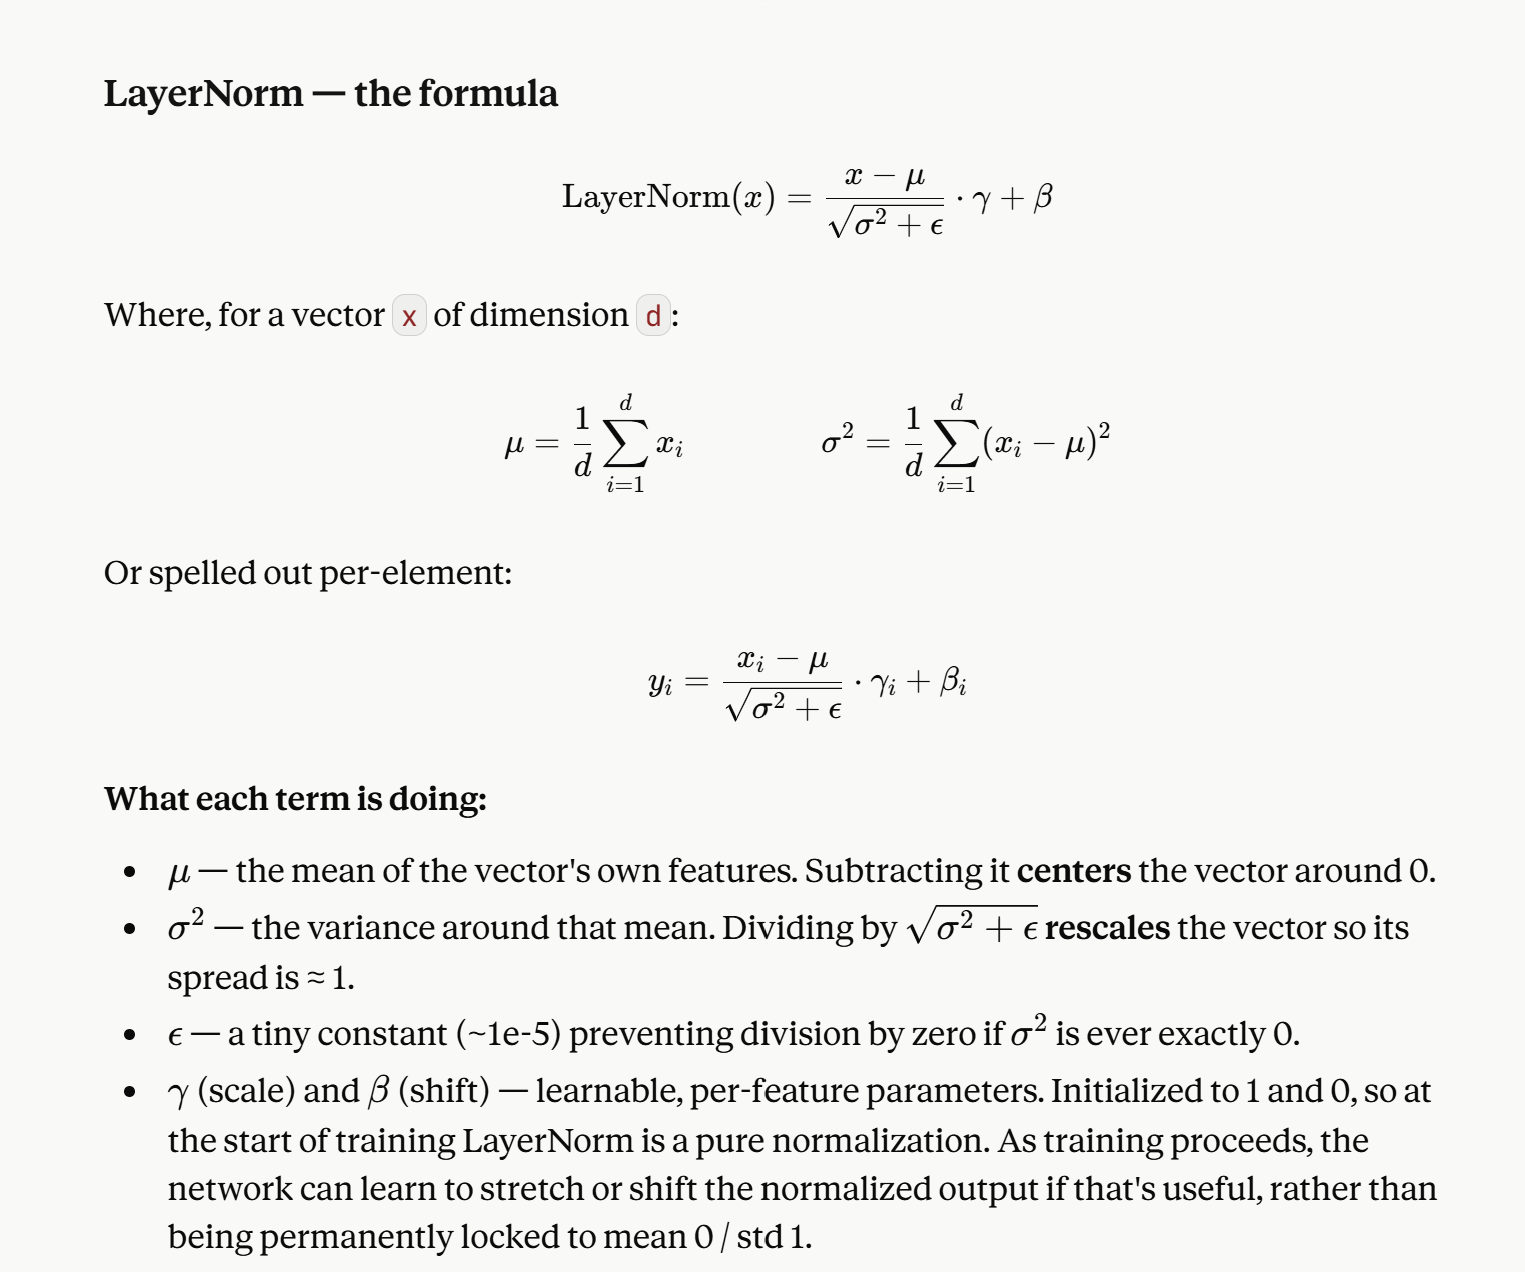

In [252]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))   # γ, learnable
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # β, learnable

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        
        return self.scale * norm_x + self.shift

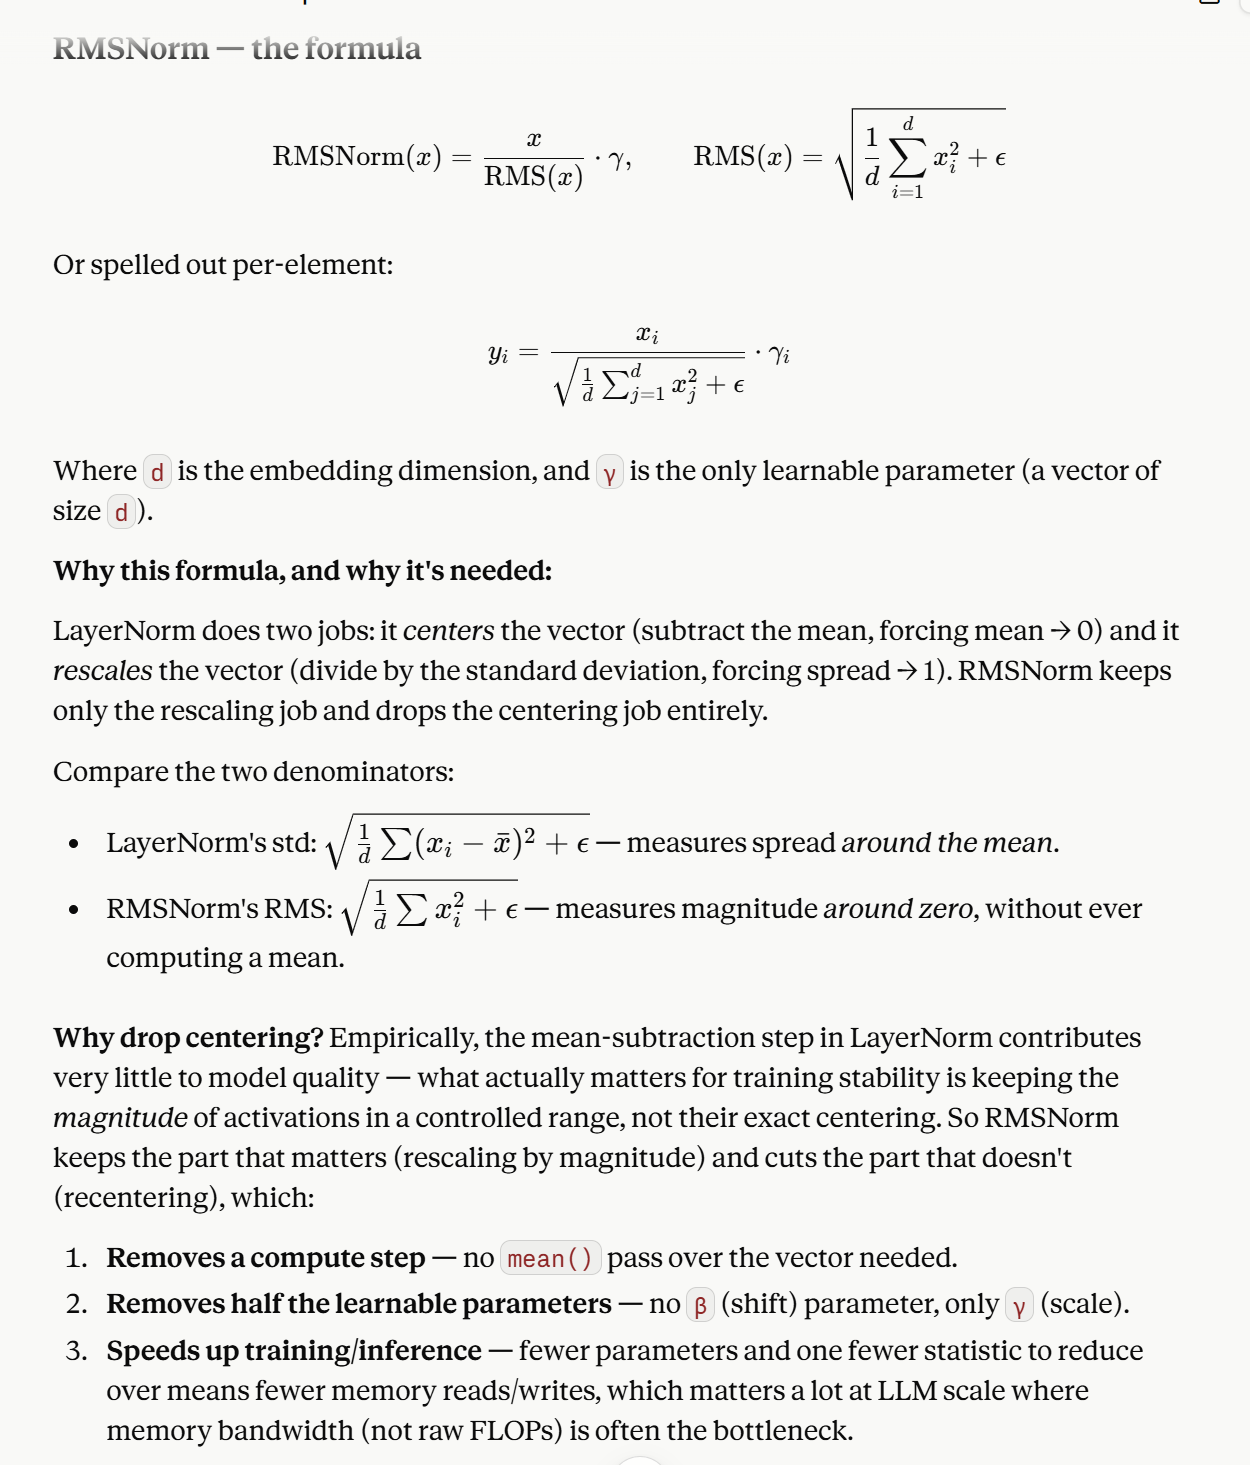

In [253]:
class RMSNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))  # only γ, no β

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (x / rms) * self.scale

In [254]:
## Feedforward implementation

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [255]:
import torch.nn.functional as F

In [256]:
## Modern Variant of Feedforward: SwiGLU
class SwiGLUFeedForward(nn.Module):
    def __init__(self, emb_dim, hidden_dim):
        super().__init__()
        self.gate_proj = nn.Linear(emb_dim, hidden_dim, bias=False)
        self.up_proj   = nn.Linear(emb_dim, hidden_dim, bias=False)
        self.down_proj = nn.Linear(hidden_dim, emb_dim, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

In [257]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"], context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"], qkv_bias=cfg["qkv_bias"]
        )

        self.ffn = FeedForward(cfg)
        self.norm1 = LayerNorm(emb_dim=cfg['emb_dim'])
        self.norm2 = LayerNorm(emb_dim=cfg['emb_dim'])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.Sequential(
            *[
                TransformerBlock(cfg)
                for _ in range(cfg['n_layers'])
            ]
        )
        self.final_norm = LayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(
            cfg['emb_dim'], cfg['vocab_size'], bias=False
        )
        
    def forward(self, input_ids):
        batch_size, seq_len = input_ids.shape
        tok_embeds = self.tok_emb(input_ids)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=input_ids.device))
        x = tok_embeds + pos_embeds
        x = self.dropout(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

#### Test Generation

In [319]:
idx

tensor([[6109, 2239, 2753,  345]])

In [322]:
idx[:, -1024:]

tensor([[6109, 2239, 2753,  345]])

In [259]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        # 1. Crop to the last `context_size` tokens (model can't see further back)
        idx_cond = idx[:, -context_size:]

        # 2. Forward pass -- no gradients needed at inference time
        with torch.no_grad():
            logits = model(idx_cond)

        # 3. Only care about the prediction for the NEXT token,
        #    which comes from the LAST position in the sequence
        logits = logits[:, -1, :]  # (batch, vocab_size)

        # 4. Convert logits to probabilities
        probas = torch.softmax(logits, dim=-1)

        # 5. Greedy decoding: pick the single most likely next token
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # 6. Append it to the running sequence, then repeat
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [260]:
torch.manual_seed(123)

In [261]:
model = GPTModel(GPT_CONFIG_124m)

In [262]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query

In [263]:
idx = torch.tensor(tokenizer.encode("Every step takes you")).unsqueeze(0)
idx.shape

torch.Size([1, 4])

In [318]:
idx

tensor([[6109, 2239, 2753,  345]])

In [264]:
out = generate_text_simple(model, idx, 6, context_size=GPT_CONFIG_124m['context_length'])

In [265]:
out

tensor([[ 6109,  2239,  2753,   345, 20860, 27234, 32708, 25564, 11056, 29083]])

In [266]:
out.shape

torch.Size([1, 10])

In [267]:
tokenizer.decode(out.squeeze(0).tolist())

'Every step takes youcommunications factualDar Cardinalmers filtered'

In [268]:
start_context_ids = [15496, 11, 314, 716]  # stand-in for tokenizer.encode("Hello, I am")
print("Starting token IDs:", start_context_ids)

encoded_tensor = torch.tensor(start_context_ids).unsqueeze(0)  # add batch dim -> (1, seq_len)
print("Encoded tensor shape:", encoded_tensor.shape)

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124m)
model.eval()  # disable dropout for generation -- we want deterministic behavior

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124m["context_length"]
)

print("\nOutput token IDs:", out)
print("Output shape:", out.shape)
print("\n(In your notebook: tokenizer.decode(out.squeeze(0).tolist()) turns this back into text)")

Starting token IDs: [15496, 11, 314, 716]
Encoded tensor shape: torch.Size([1, 4])



Output token IDs: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output shape: torch.Size([1, 10])

(In your notebook: tokenizer.decode(out.squeeze(0).tolist()) turns this back into text)


In [269]:
tokenizer.decode(out.squeeze(0).tolist())

'Hello, I am Featureiman Byeswickattribute argue'

In [270]:

with open("../SebastianRakscha/the-verdict.txt", "r", encoding="utf-8") as f: # added ../01_main-chapter-code/
    raw_text = f.read()

raw_text[:20]

'I HAD always thought'

In [271]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

In [272]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = text_to_token_ids(start_context, tokenizer)
print("token_ids.shape:", token_ids.shape)
print()
print(token_ids)

token_ids.shape: torch.Size([1, 4])

tensor([[6109, 3626, 6100,  345]])


In [273]:
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

token_ids_to_text(token_ids, tokenizer)

'Every effort moves you'

In [274]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124m["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you Aeiman Byeswickattributeometer inspector Normandy freezerigrate


#### Calculating the text Generation Loss: cross entropy and perplexity

In [275]:
GPT_CONFIG_124m = {
    "vocab_size": 50257,  #Vocabulary size
    "context_length": 256,   # Context length
    "emb_dim": 768,   # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,   # Number of layers
    "drop_rate": 0.1,   # Dropout rate
    "qkv_bias": False   # Query-key-Value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124m)
model.eval();

In [276]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query)

In [277]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [278]:
x = inputs[0]
y = targets[0]
x, y

(tensor([16833,  3626,  6100]), tensor([3626, 6100,  345]))

In [279]:
with torch.no_grad():
    logits = model(inputs)

logits.shape

torch.Size([2, 3, 50257])

In [280]:
probas = torch.softmax(logits, dim=-1)
probas.shape

torch.Size([2, 3, 50257])

In [281]:
probas

tensor([[[1.8851e-05, 1.5173e-05, 1.1687e-05,  ..., 2.2408e-05,
          6.9776e-06, 1.8775e-05],
         [9.1574e-06, 1.0062e-05, 7.8784e-06,  ..., 2.9089e-05,
          6.0105e-06, 1.3569e-05],
         [2.9875e-05, 8.8504e-06, 1.5741e-05,  ..., 3.5458e-05,
          1.4094e-05, 1.3525e-05]],

        [[1.2561e-05, 2.0537e-05, 1.4331e-05,  ..., 1.0388e-05,
          3.4784e-05, 1.4238e-05],
         [7.2733e-06, 1.7863e-05, 1.0564e-05,  ..., 2.1206e-05,
          1.1390e-05, 1.5558e-05],
         [2.9495e-05, 3.3605e-05, 4.1032e-05,  ..., 6.5251e-06,
          5.8202e-05, 1.3697e-05]]])

In [282]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs\n", token_ids)

Token IDs
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [283]:
print(f"Target batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Output batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Target batch 1:  effort moves you
Output batch 1:  Armed heNetflix


In [284]:
targets[0]

tensor([3626, 6100,  345])

In [285]:
targets

tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])

In [286]:
probas[0, [0, 1, 2], targets[0]]

tensor([7.4536e-05, 3.1061e-05, 1.1563e-05])

In [287]:
probas[0, 0, 3626]

tensor(7.4536e-05)

In [288]:
probas[0, 1, 6100]

tensor(3.1061e-05)

In [289]:
probas[0, 2, 6100]

tensor(1.0943e-05)

In [290]:
text_idx = 0
target_probab_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probab_1)

print("\n\n")

text_idx = 1
target_probab_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probab_2)

Text 1: tensor([7.4536e-05, 3.1061e-05, 1.1563e-05])



Text 2: tensor([1.0337e-05, 5.6771e-05, 4.7559e-06])


In [291]:
log_probas = torch.log(torch.concat((target_probab_1, target_probab_2)))
log_probas

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7765, -12.2561])

In [292]:
-1*torch.mean(log_probas)

tensor(10.7940)

In [293]:
logits.flatten(0, 1).shape

torch.Size([6, 50257])

In [294]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)                      # (1, seq_len, vocab_size)
    loss = F.cross_entropy(
        logits.flatten(0, 1),                          # (seq_len, vocab_size)
        target_batch.flatten()                          # (seq_len,)
    )
    return loss

loss = calc_loss_batch(inputs, targets, model, device="cpu")

In [295]:
loss

tensor(10.7940, grad_fn=<NllLossBackward0>)

#### Calculating the training and validation set losses

In [296]:
with open("../SebastianRakscha/the-verdict.txt", "r", encoding="utf-8") as f: # added ../01_main-chapter-code/
    raw_text = f.read()

raw_text[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [297]:
total_characters = len(raw_text)
total_tokens = len(tokenizer.encode(raw_text))

print(f"Total character: {total_characters}")
print(f"The total token: {total_tokens}")

Total character: 20479
The total token: 5145


In [298]:
## splitting the data intro train and validation set
train_ratio = 0.90
split_idx = int(train_ratio * total_characters)
train_data = raw_text[: split_idx]
val_data = raw_text[split_idx: ]

len(train_data)

18431

In [299]:
train_data[-20:]

"y called my 'techniq"

In [300]:
GPT_CONFIG_124m

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [301]:
torch.manual_seed(123)

train_loader = create_dataloader(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124m['context_length'],
    stride=GPT_CONFIG_124m['context_length'],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124m['context_length'],
    stride=GPT_CONFIG_124m['context_length'],
    drop_last=False,
    shuffle=False,
    num_workers=0

)

In [302]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [303]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [304]:
total_tokens

5145

In [306]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [307]:
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query)

In [305]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)                      # (1, seq_len, vocab_size)
    loss = F.cross_entropy(
        logits.flatten(0, 1),                          # (seq_len, vocab_size)
        target_batch.flatten()                          # (seq_len,)
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()
    return total_loss / num_batches

In [308]:
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(F"Training loss: {train_loss}")
print(f"Validation loss: {val_loss}")

Training loss: 10.98758167690701
Validation loss: 10.98110580444336


In [309]:
# perplexity
torch.exp(torch.tensor(train_loss))

tensor(59135.1797)

In [310]:
GPT_CONFIG_124m['vocab_size']

50257

In [311]:
# perplexity
torch.exp(torch.tensor(val_loss))

tensor(58753.4883)

### Training an LLM

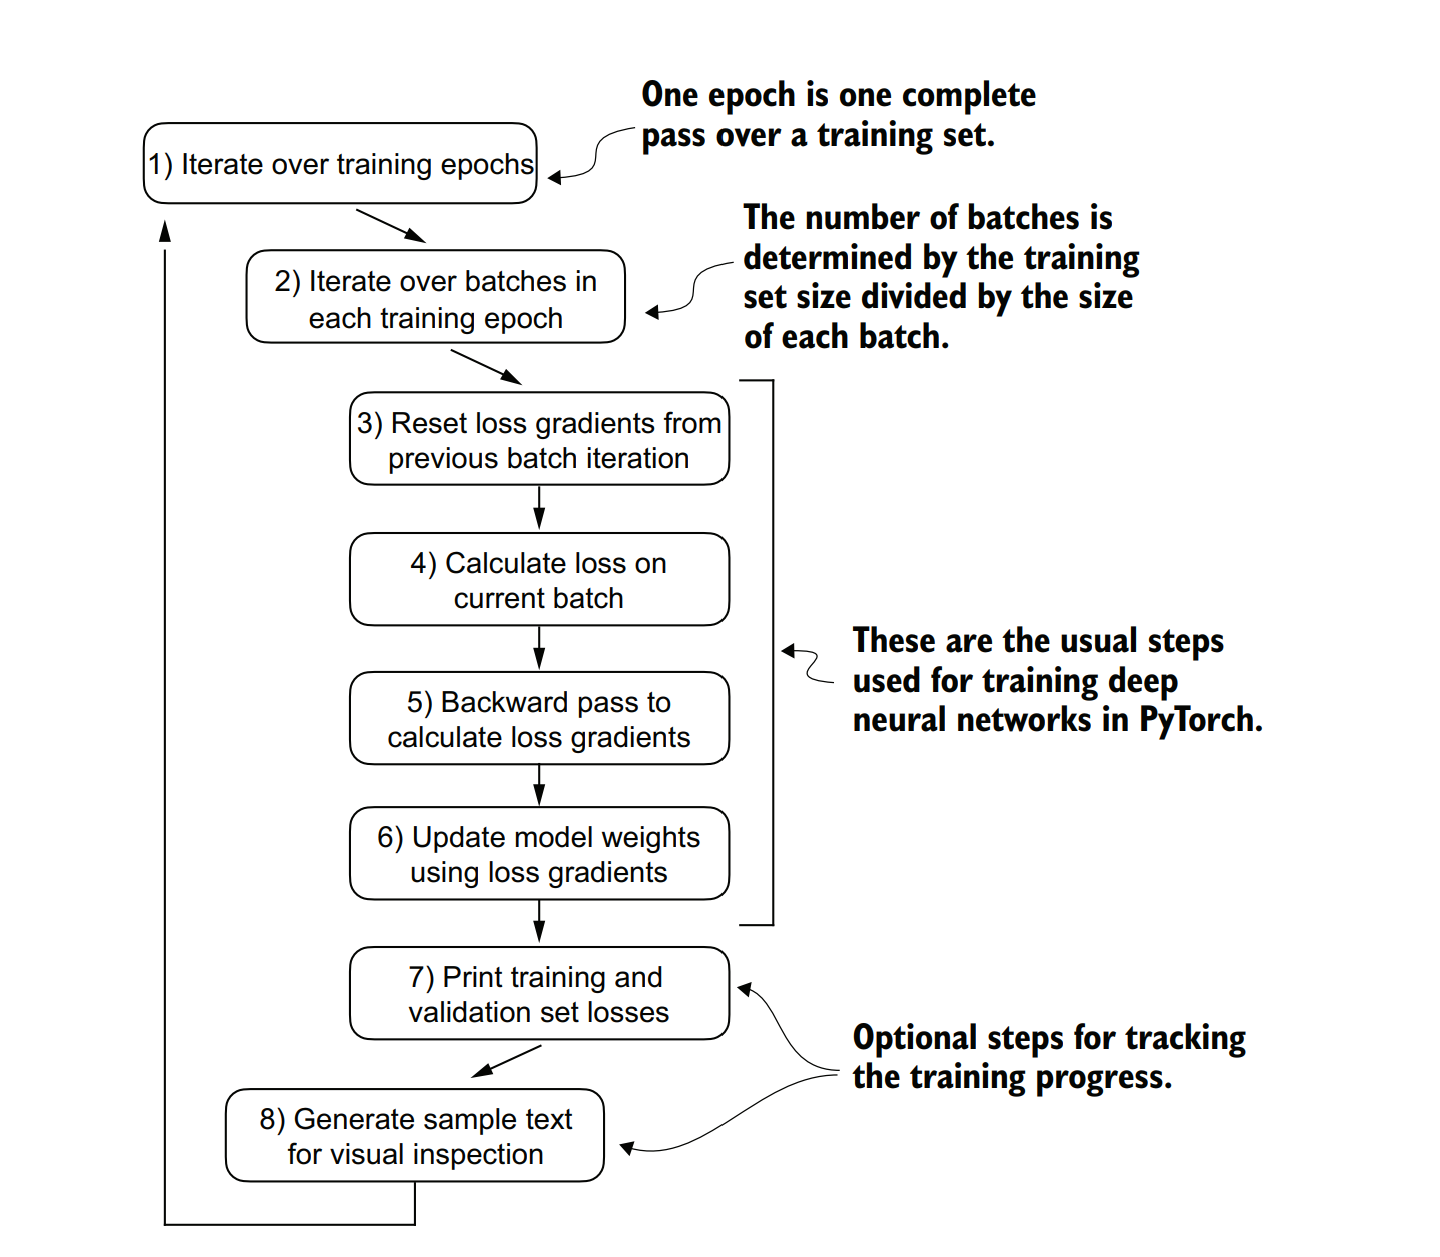

In [317]:
model.pos_emb

Embedding(256, 768)

In [ ]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Pytorch Training convention
```python
for epoch in range(num_epochs):
    # ---- training ----
    model.train()
    total_train_loss = 0.0
    for input_batch, target_batch in train_loader:
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)

        optimizer.zero_grad()
        logits = model(input_batch)
        loss = criterion(logits.flatten(0, 1), target_batch.flatten())
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # ---- validation ----
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for input_batch, target_batch in val_loader:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            logits = model(input_batch)
            loss = criterion(logits.flatten(0, 1), target_batch.flatten())
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {avg_train_loss:.4f} | val loss: {avg_val_loss:.4f}")
```

In [325]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokesn_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs): # outer loop: full passes over the dataset
        model.train()

        for input_batch, target_batch in train_loader: # inner loop: one batch at a time
            
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()

            global_step += 1
            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(train_loader, model, device, eval_iter)
                    val_loss = calc_loss_loader(val_loader, model, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokesn_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                model.train()

        ## Print a simple text after each epoch
        generate_and_print_sample(model, tokenizer, device, start_context)
        # -- checkpoint --
        # torch.save(model.state_dict(), f"checkpoint_epoch{epoch+1}.pt")
    return train_losses, val_losses, track_tokesn_seen

In [326]:
torch.manual_seed(123)
import time
start_time = time.time()
model = GPTModel(GPT_CONFIG_124m)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339

Every effort moves you,,,,,,,,,,,,.






































Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616

Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,

Ep 3 (Step 000020): Train loss 5.723, Val loss 6.598
Ep 3 (Step 000025): Train loss 5.204, Val loss 6.351

Every effort moves you, and I had been.













































Ep 4 (Step 000030): Train loss 4.420, Val loss 6.279
Ep 4 (Step 000035): Train loss 4.071, Val loss 6.226

Every effort moves you know the

























"I he had the donkey and I had the and I had the donkey and down the room, I had

Ep 5 (Step 000040): Train loss 3.733, Val loss 6.160

Every effort moves you know it was not that the picture--I had the fact by

This generates text **autoregressively**: at each step, feed the current sequence in, take the logits for the last position only (`logits[:, -1, :]`), pick the most likely next token (`argmax` — greedy, simplest possible decoding strategy, no sampling randomness), append it, and repeat. `idx_cond = encoded[:, -context_size:]` guards against feeding in more tokens than your model's `context_length` supports (important since your causal mask buffer is only sized up to `context_length`).

In [327]:
def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=50):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]  # or however you store context_length
    encoded = tokenizer.encode(start_context)
    encoded = torch.tensor(encoded).unsqueeze(0).to(device)  # (1, seq_len)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # only feed the last `context_size` tokens (in case sequence grows beyond it)
            idx_cond = encoded[:, -context_size:]
            logits = model(idx_cond)               # (1, seq_len, vocab_size)
            logits = logits[:, -1, :]               # only care about the next-token prediction
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.argmax(probs, dim=-1, keepdim=True)  # greedy decoding
            encoded = torch.cat([encoded, next_token], dim=1)

    decoded_text = tokenizer.decode(encoded.squeeze(0).tolist())
    print(f"\n{decoded_text}\n")
    model.train()

In [328]:
import math

def get_lr(step, warmup_steps, max_steps, max_lr, min_lr):
    # 1) linear warmup for the first warmup_steps
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps

    # 2) after max_steps, just stay at min_lr
    if step > max_steps:
        return min_lr

    # 3) in between: cosine decay from max_lr down to min_lr
    decay_ratio = (step - warmup_steps) / (max_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))  # 1 -> 0
    return min_lr + coeff * (max_lr - min_lr)

In [334]:
def train_model(model, train_loader, val_loader, optimizer, device,
                 num_epochs, eval_freq, eval_iter, warmup_steps, max_steps,
                 max_lr, min_lr, tokenizer, start_context):
    train_losses, val_losses = [], []
    tokens_seen, global_step = 0, -1          # <-- ADD tokens_seen counter here

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            global_step += 1
            tokens_seen += input_batch.numel()   # <-- ADD this line

            lr = get_lr(global_step, warmup_steps, max_steps, max_lr, min_lr)
            for pg in optimizer.param_groups:
                pg["lr"] = lr

            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    train_loss = calc_loss_loader(train_loader, model, device, eval_iter)
                    val_loss = calc_loss_loader(val_loader, model, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"step {global_step} | lr {lr:.2e} | tokens {tokens_seen} | "
                      f"train {train_loss:.3f} | val {val_loss:.3f}")
                model.train()

        generate_and_print_sample(model, tokenizer, device, start_context)
        torch.save(model.state_dict(), f"checkpoint_epoch{epoch+1}.pt")

    return train_losses, val_losses, tokens_seen   # <-- ADD tokens_seen here

In [335]:
torch.manual_seed(123)
import time
start_time = time.time()

model = GPTModel(GPT_CONFIG_124m)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10

# --- values train_model needs for its LR schedule ---
max_steps = num_epochs * len(train_loader)     # total optimizer steps across all epochs
warmup_steps = int(0.1 * max_steps)            # warm up over ~first 10% of training
max_lr = 0.0004                                 # matches the optimizer's initial lr
min_lr = 0.1 * max_lr                            # decay floor, common convention

train_losses, val_losses, tokens_seen = train_model(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    warmup_steps=warmup_steps, max_steps=max_steps,
    max_lr=max_lr, min_lr=min_lr,
    tokenizer=tokenizer, start_context="Every effort moves you"
)

end_time = time.time()
print(f"Training completed in {(end_time - start_time)/60:.2f} minutes")

step 0 | lr 4.44e-05 | tokens 512 | train 10.763 | val 10.794
step 5 | lr 2.67e-04 | tokens 3072 | train 8.965 | val 9.176

Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

step 10 | lr 4.00e-04 | tokens 5632 | train 7.421 | val 7.725
step 15 | lr 3.95e-04 | tokens 8192 | train 6.271 | val 6.790

Every effort moves you, the, the, the, the, the, the, the.




































step 20 | lr 3.84e-04 | tokens 10752 | train 5.828 | val 6.563
step 25 | lr 3.66e-04 | tokens 13312 | train 5.566 | val 6.461

Every effort moves you, and, and the of the of the to the to the of the of the, and I had, and, I had to the of the of the of the to the of the of the of the of the of the, and, and

step 30 | lr 3.44e-04 | tokens 15872 | train 4.720 | val 6.383
step 35 | lr 3.16e-04 | tokens 18432 | train 4.116 | val 6.205

Every effort moves you, I was. Gisburn, I was a little the picture. Gisburn, I was--and, I was. Gisburn, I was a little the picture to the pictur

- `model`: your GPT-style model (built from your MultiHeadAttention blocks).
- `train_loader` / `val_loader`: your `DataLoaders` (the `create_dataloader(...)` pattern from earlier), one for training data, one for held-out validation data.
- `optimizer`: e.g., `torch.optim.AdamW(model.parameters(), lr=...)`.
- `device`: `"cuda"`, `"mps"`, or `"cpu"` — where tensors get moved to for computation.
- `num_epochs`: how many full passes over `train_loader`.
- `eval_freq`: how often (in steps) to pause and check train/val loss.
- `eval_iter`: how many batches to average over when evaluating (not the whole val set — just a sample, for speed).
- `warmup_steps`, `max_steps`, `max_lr`, `min_lr`: control the learning rate schedule (explained below).
- `tokenizer`: needed to decode generated token IDs back into text for the qualitative sample.
- `start_context`: a text prompt (e.g., `"Once upon a time"`) used to generate a sample continuation after each epoch, so you can read what the model is producing, not just watch loss numbers.